<a href="https://colab.research.google.com/github/gurpreetsahotasingh288-gif/Python_program/blob/main/LSTM%26RRN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

In [ ]:
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
path

100%|██████████| 242M/242M [00:04<00:00, 61.9MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2'

In [ ]:
csv_file = os.path.join(path,"Reviews.csv")
print(f"csv file path : {csv_file}")
df = pd.read_csv(csv_file)
df.head(2)

csv file path : /root/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2/Reviews.csv


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df_clean=df[['Text','Score']]
df_clean.head(2)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1


In [ ]:
score_count=df_clean['Score'].value_counts().sort_index()
score_count

#for score,count in score_count.items():
# percentage=(count/len(df_clean))*100
# print(f"{score} stars:{percentage:.2f}%")

score_pct=(df_clean['Score'].value_counts(normalize=True).sort_index()*100)
score_pct.apply(lambda x:f"{x:.2f}%")

,proportion
Score,
1,9.19%
2,5.23%
3,7.50%
4,14.19%
5,63.88%


In [ ]:
for score in [1,2,3,4,5]:
  sample_review=df_clean[df_clean['Score']==score]['Text'].iloc[0]
  print(f"\n⭐ {score}-STAR REVIEW:")
  print(f"Sample Review: {sample_review[:200]}")


⭐ 1-STAR REVIEW:
Sample Review: Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

⭐ 2-STAR REVIEW:
Sample Review: If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor

⭐ 3-STAR REVIEW:
Sample Review: This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't 

⭐ 4-STAR REVIEW:
Sample Review: This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powd

⭐ 5-STAR REVIEW:
Sample Review: I have bought several of the Vitality can

In [ ]:
df_clean['text_length']=df_clean['Text'].str.len()
df_clean['word_count']=df_clean['Text'].str.split().str.len()

/tmp/ipython-input-37726576.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length']=df_clean['Text'].str.len()
/tmp/ipython-input-37726576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count']=df_clean['Text'].str.split().str.len()


In [ ]:
df_clean.head()

,Text,Score,text_length,word_count
0,I have bought several of the Vitality canned d...,5,263,48
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31
2,This is a confection that has been around a fe...,4,509,94
3,If you are looking for the secret ingredient i...,2,219,41
4,Great taffy at a great price. There was a wid...,5,140,27


Text(0, 0.5, 'Number of Reviews')

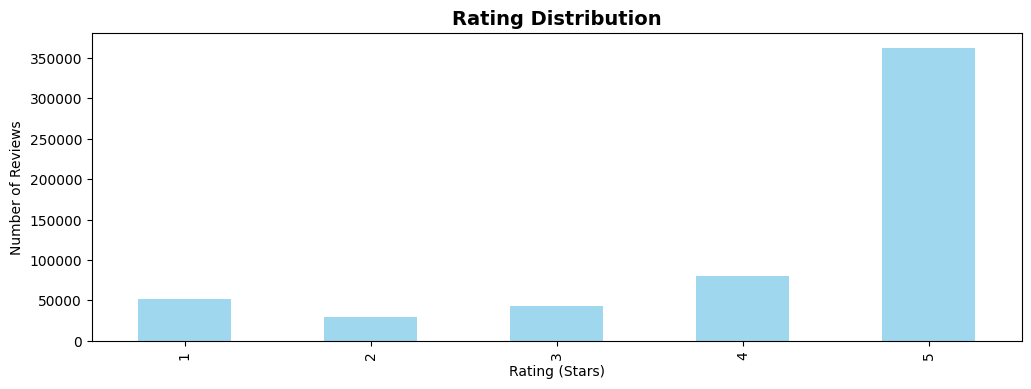

In [ ]:
plt.figure(figsize=(12,4))
score_counts=df_clean['Score'].value_counts().sort_index()
score_counts.plot(kind='bar',color='skyblue',alpha=0.8)
plt.title("Rating Distribution",fontsize=14,fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel("Number of Reviews")

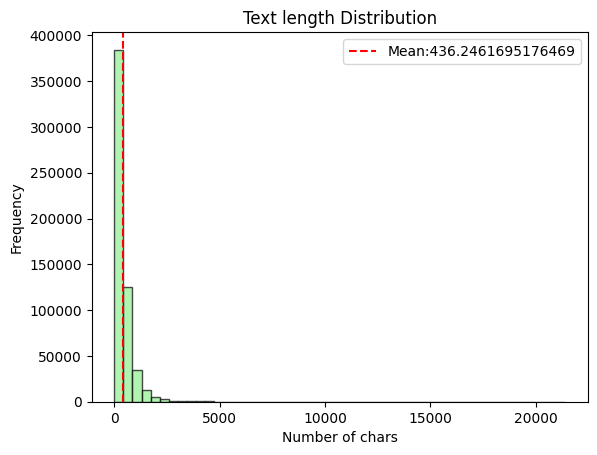

In [ ]:
plt.hist(df_clean['text_length'],bins=50,alpha=0.7,color='lightgreen',edgecolor='black')
plt.title("Text length Distribution")
plt.xlabel("Number of chars")
plt.ylabel("Frequency")
plt.axvline(df_clean['text_length'].mean(),color='red',linestyle='--',
            label=f"Mean:{df_clean['text_length'].mean()}")
plt.legend()

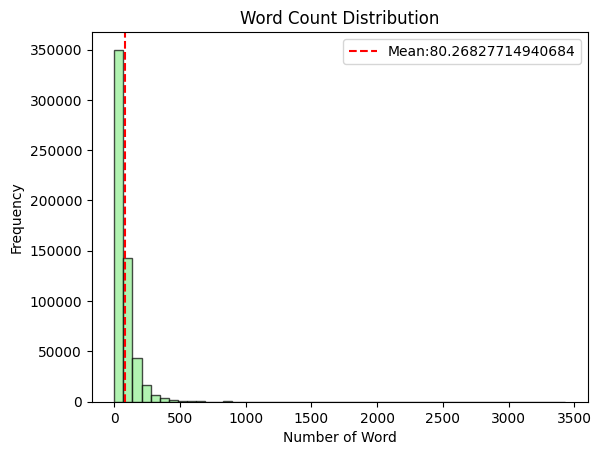

In [ ]:
plt.hist(df_clean['word_count'],bins=50,alpha=0.7,color='lightgreen',edgecolor='black')
plt.title("Word Count Distribution")
plt.xlabel("Number of Word")
plt.ylabel("Frequency")
plt.axvline(df_clean['word_count'].mean(),color='red',linestyle='--',
            label=f"Mean:{df_clean['word_count'].mean()}")
plt.legend()

In [ ]:
df_binary=df_clean[df_clean['Score']!=3].copy()
df_binary['sentiment']=(df_binary['Score']>=4).astype(int)

In [ ]:
df_binary['Score'].value_counts()

,count
Score,
5,363102
4,80654
1,52264
2,29743


In [ ]:
df[df['Score']==3]['Text'].iloc[0]

"This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again."

In [ ]:
df_binary.head(4)

,Text,Score,text_length,word_count,sentiment
0,I have bought several of the Vitality canned d...,5,263,48,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31,0
2,This is a confection that has been around a fe...,4,509,94,1
3,If you are looking for the secret ingredient i...,2,219,41,0


In [ ]:
print(f"Negative (1-2):{sum(df_binary['sentiment']==0):,}")
print(f"Positive (4-5):{sum(df_binary['sentiment']==1):,}")

Negative (1-2):82,007
Positive (4-5):443,756


In [ ]:
negative_pct=(sum(df_binary['sentiment']==0)/len(df_binary))*100
positive_pct=(sum(df_binary['sentiment']==1)/len(df_binary))*100
print(f"negative_pct:{negative_pct:.2f}")
print(f"positive_pct:{positive_pct:.2f}")

negative_pct:15.60
positive_pct:84.40


In [ ]:
from sklearn.utils import resample

In [ ]:
neg_reviews=df_binary[df_binary['sentiment']==0]
pos_reviews=df_binary[df_binary['sentiment']==1]

In [ ]:
#undersampling
n_minority=len(neg_reviews)
n_minority

82007

In [ ]:
pos_downsampled=resample(pos_reviews,
                         replace=False,
                         n_samples=n_minority,
                         random_state=42)
df_balanced=pd.concat([neg_reviews,pos_downsampled])

In [ ]:
#random shuffle
df_balanced=df_balanced.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
print(f"Neg:{sum(df_balanced['sentiment']==0):,}({sum(df_balanced['sentiment']==0)/len(df_balanced)*100})")
print(f"Pos:{sum(df_balanced['sentiment']==1):,}({sum(df_balanced['sentiment']==1)/len(df_balanced)*100})")

Neg:82,007(50.0)
Pos:82,007(50.0)


In [ ]:
df_balanced.head()

,Text,Score,text_length,word_count,sentiment
0,I found this Harissa Paste somewhat overpoweri...,1,182,34,0
1,I was really disappointed with this instant co...,2,162,26,0
2,I evaluated this coffee blend while travelling...,2,403,69,0
3,I was very excited to find a cheaper cider. Ho...,1,320,61,0
4,"I have fallen in love with boondi, although I ...",5,179,36,1


In [ ]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164014 entries, 0 to 164013
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Text         164014 non-null  object
 1   Score        164014 non-null  int64 
 2   text_length  164014 non-null  int64 
 3   word_count   164014 non-null  int64 
 4   sentiment    164014 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 6.3+ MB


In [ ]:
import re
def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  text=' '.join(text.split())
  return text

In [ ]:
df_balanced['clean_text']=df_balanced['Text'].apply(clean_text)

In [ ]:
df_balanced.head(2)

,Text,Score,text_length,word_count,sentiment,clean_text
0,I found this Harissa Paste somewhat overpoweri...,1,182,34,0,i found this harissa paste somewhat overpoweri...
1,I was really disappointed with this instant co...,2,162,26,0,i was really disappointed with this instant co...


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
MAX_FEATURES=10000
MAX_LEN=100
X=df_balanced['clean_text'].values
y=df_balanced['sentiment'].values

tokenizer=Tokenizer(num_words=MAX_FEATURES,oov_token="<OOV>")
tokenizer.fit_on_texts(X)
X_sequences=tokenizer.texts_to_sequences(X)

In [ ]:
tokenizer

In [ ]:
X_sequences[0]

[3,
 125,
 9,
 1,
 1334,
 957,
 1252,
 25,
 676,
 6,
 394,
 13,
 3,
 19,
 87,
 229,
 5,
 3566,
 792,
 7,
 16,
 15,
 6,
 14,
 32,
 4,
 3,
 749,
 66,
 981,
 218,
 289,
 5,
 615]

In [ ]:
X_padded=pad_sequences(X_sequences,maxlen=MAX_LEN,padding='post',truncating='post')

In [ ]:
len(X_padded[0])

100

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,Dense,Dropout

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_padded,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
def create_model():
  model=Sequential([
      Embedding(input_dim=MAX_FEATURES,output_dim=128,input_length=MAX_LEN),
      SimpleRNN(units=64,return_sequences=False),
      Dropout(0.5),
      Dense(32,activation='relu'),
      Dense(1,activation='sigmoid')
  ])
  return model

In [ ]:
rnn_model=create_model()
rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_history=rnn_model.fit(
    X_train,y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 60s 69ms/step - accuracy: 0.5191 - loss: 0.6924 - val_accuracy: 0.5397 - val_loss: 0.6813
Epoch 2/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step - accuracy: 0.5613 - loss: 0.6651 - val_accuracy: 0.5521 - val_loss: 0.6697
Epoch 3/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 80s 69ms/step - accuracy: 0.5996 - loss: 0.6162 - val_accuracy: 0.5538 - val_loss: 0.6780
Epoch 4/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - accuracy: 0.6293 - loss: 0.5702 - val_accuracy: 0.5644 - val_loss: 0.7127
Epoch 5/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - accuracy: 0.6539 - loss: 0.5348 - val_accuracy: 0.5792 - val_loss: 0.7678
Epoch 6/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 57s 69ms/step - accuracy: 0.6810 - loss: 0.4959 - val_accuracy: 0.5931 - val_loss: 0.8227
Epoch 7/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 57s 69ms/step - accuracy: 0.7016 - loss: 0.4828 - val_accuracy: 0.5885 - val_loss: 0.8044
Epoch 8/15
821/821 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.7104 - loss: 0.4677 - 

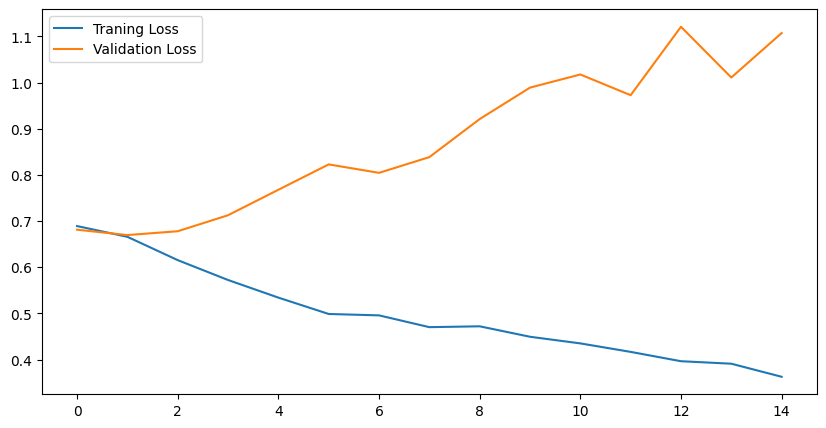

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['loss'],label='Traning Loss')
plt.plot(rnn_history.history['val_loss'],label='Validation Loss')
plt.legend()


In [ ]:
param_grid={
    "model_type":['rnn','lstm'],
    "embedding_dim":[64,128],
    "units":[32,64,128],
    "dropout_rate":[0.3,0.5],
    "learning_rate":[0.001,0.01]
}


In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
def create_model_with_params(model_type='lstm',embedding_dim=128,units=64,dropout_rate=0.5,learning_rate=0.01):
  model=Sequential([
      Embedding(MAX_FEATURES,embedding_dim,input_length=MAX_LEN)
  ])

  if model_type=='lstm':
    model.add(LSTM(units,return_sequences=False))
  else:
    model.add(SimpleRNN(units,return_sequences=False))

  model.add(Dropout(dropout_rate))
  model.add(Dense(32,activation='relu'))
  model.add(Dense(1,activation='sigmoid'))
  model.compile(
      optimizer=Adam(learning_rate=learning_rate),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

In [ ]:
def random_search(n_trails=8):
  results=[]
  np.random.seed(42)

  for i in range(n_trails):
    params={
        "model_type":str(np.random.choice(param_grid['model_type'])),
        "embedding_dim":int(np.random.choice(param_grid['embedding_dim'])),
        "units":int(np.random.choice(param_grid['units'])),
        "dropout_rate":float(np.random.choice(param_grid['dropout_rate'])),
        "learning_rate":float(np.random.choice(param_grid['learning_rate']))

    }
    print(f"\n---Trail {i+1}/{n_trails}------")
    print(f"PARAMS:{params}")

    try:
      model=create_model_with_params(**params)
      history=model.fit(
          X_train,y_train,
          batch_size=128,
          epochs=5,
          validation_split=0.2
      )
      val_accuracy=max(history.history['val_accuracy'])
      results.append({
          'trail':i+1,
          'params':params,
          "val_accuracy":val_accuracy,
          "model":model
      })
      print(f"Validation Accurat: {val_accuracy:.2f}")
    except Exception as e:
      print(f"Error in trail:{str(e)}")
  return results

In [ ]:
random_search(8)


---Trail 1/8------
PARAMS:{'model_type': 'rnn', 'embedding_dim': 128, 'units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.5318 - loss: 0.6890 - val_accuracy: 0.5451 - val_loss: 0.6826
Epoch 2/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 78s 57ms/step - accuracy: 0.5825 - loss: 0.6455 - val_accuracy: 0.5805 - val_loss: 0.6536
Epoch 3/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - accuracy: 0.6126 - loss: 0.5852 - val_accuracy: 0.5594 - val_loss: 0.6483
Epoch 4/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - accuracy: 0.6407 - loss: 0.5374 - val_accuracy: 0.5901 - val_loss: 0.7047
Epoch 5/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - accuracy: 0.6532 - loss: 0.5224 - val_accuracy: 0.5937 - val_loss: 0.7161
Validation Accurat: 0.59

---Trail 2/8------
PARAMS:{'model_type': 'lstm', 'embedding_dim': 64, 'units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.01}
Epoch 1/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 69s 79ms/step - accuracy: 0.6722 - loss: 0.5410 - val_accuracy: 0.9058 - val_loss: 0.2423
Epoch 2/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - accuracy: 0.9204 -

[{'trail': 1,
  'params': {'model_type': 'rnn',
   'embedding_dim': 128,
   'units': 32,
   'dropout_rate': 0.3,
   'learning_rate': 0.001},
  'val_accuracy': 0.5937202572822571,
  'model': <Sequential name=sequential_1, built=True>},
 {'trail': 2,
  'params': {'model_type': 'lstm',
   'embedding_dim': 64,
   'units': 32,
   'dropout_rate': 0.3,
   'learning_rate': 0.01},
  'val_accuracy': 0.9176923632621765,
  'model': <Sequential name=sequential_2, built=True>},
 {'trail': 3,
  'params': {'model_type': 'rnn',
   'embedding_dim': 64,
   'units': 128,
   'dropout_rate': 0.3,
   'learning_rate': 0.01},
  'val_accuracy': 0.5824029445648193,
  'model': <Sequential name=sequential_3, built=True>},
 {'trail': 4,
  'params': {'model_type': 'rnn',
   'embedding_dim': 128,
   'units': 128,
   'dropout_rate': 0.5,
   'learning_rate': 0.001},
  'val_accuracy': 0.5678085684776306,
  'model': <Sequential name=sequential_4, built=True>},
 {'trail': 5,
  'params': {'model_type': 'lstm',
   'embeddin